#Sarcasm Detection

In [5]:
%pip install pandas numpy matplotlib seaborn wordcloud scikit-learn tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
#Import and load data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ML Imports
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Deep Learning Imports
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Bidirectional, Dropout

# Configuration
vocab_size = 10000
max_length = 100
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"

print("Libraries Imported Successfully!")

# Load Dataset
df = pd.read_json("Sarcasm_Headlines_Dataset.json", lines=True)
df = df.drop(columns=['article_link'])
df

Libraries Imported Successfully!


,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0
...,...,...
26704,american politics in moral free-fall,0
26705,america's best 20 hikes,0
26706,reparations and obama,0
26707,israeli ban targeting boycott supporters raise...,0


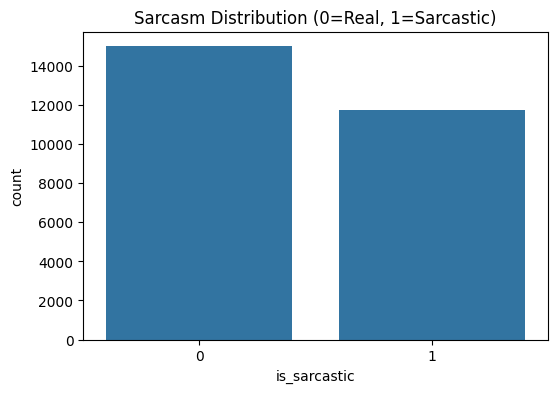

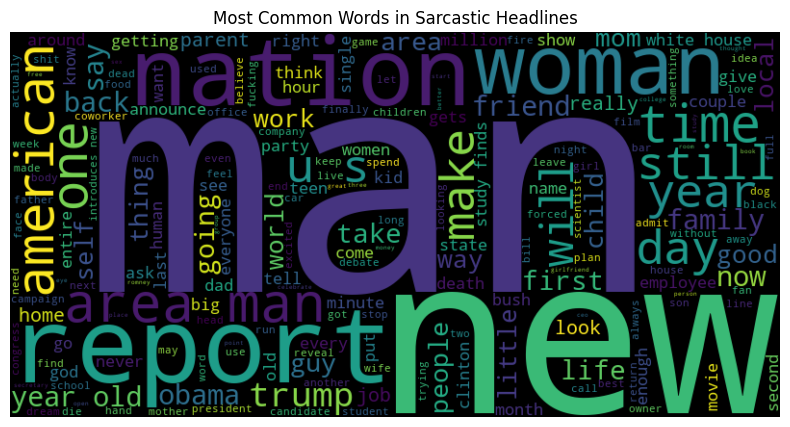

In [7]:
#EDA

# 1. Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='is_sarcastic', data=df)
plt.title("Sarcasm Distribution (0=Real, 1=Sarcastic)")
plt.show()

# 2. Word Cloud
sarcastic_text = " ".join(df[df['is_sarcastic'] == 1]['headline'])
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(sarcastic_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Sarcastic Headlines")
plt.show()

In [8]:
#Preprocessing

# --- Vectorization for Traditional ML ---
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = tfidf.fit_transform(df['headline']).toarray()
y = df['is_sarcastic']

# Split Data (We use '_ml' to keep it separate from Deep Learning data)
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

print(f"ML Data Ready: {X_train_ml.shape}")

ML Data Ready: (21367, 5000)


In [9]:
#Machine Learning Models

# --- Model 1: Naive Bayes ---
nb_model = MultinomialNB()
nb_model.fit(X_train_ml, y_train_ml)
nb_acc = accuracy_score(y_test_ml, nb_model.predict(X_test_ml))
print(f"Naive Bayes Accuracy: {nb_acc*100:.2f}%")

# --- Model 2: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
rf_model.fit(X_train_ml, y_train_ml)
rf_acc = accuracy_score(y_test_ml, rf_model.predict(X_test_ml))
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

Naive Bayes Accuracy: 78.87%
Random Forest Accuracy: 77.20%


In [10]:
# Deep Learning Prep

# --- Tokenization for Deep Learning ---
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(df['headline'])

# Convert to Sequences
sequences = tokenizer.texts_to_sequences(df['headline'])
padded = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

# Split Data (Using '_dl' variable names)
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(padded, y, test_size=0.2, random_state=42)

print(f"Deep Learning Data Ready: {X_train_dl.shape}")

Deep Learning Data Ready: (21367, 100)


In [11]:
# --- Build LSTM Model ---
model = Sequential([
    Embedding(vocab_size, 32, input_length=max_length),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(24, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

# Train
history = model.fit(X_train_dl, y_train_dl, epochs=10,
                    validation_data=(X_test_dl, y_test_dl), verbose=1)

# Final Evaluation
loss, accuracy = model.evaluate(X_test_dl, y_test_dl)
print(f"Final LSTM Accuracy: {accuracy*100:.2f}%")

Epoch 1/10


C:\Users\Shreya\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


668/668 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.5970 - loss: 0.6593 - val_accuracy: 0.7915 - val_loss: 0.5365
Epoch 2/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 29s 44ms/step - accuracy: 0.8105 - loss: 0.4425 - val_accuracy: 0.8345 - val_loss: 0.3773
Epoch 3/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 31s 47ms/step - accuracy: 0.8652 - loss: 0.3391 - val_accuracy: 0.8495 - val_loss: 0.3452
Epoch 4/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.8938 - loss: 0.2818 - val_accuracy: 0.8501 - val_loss: 0.3460
Epoch 5/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 33s 49ms/step - accuracy: 0.9138 - loss: 0.2400 - val_accuracy: 0.8562 - val_loss: 0.3375
Epoch 6/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - accuracy: 0.9298 - loss: 0.2047 - val_accuracy: 0.8559 - val_loss: 0.3533
Epoch 7/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 69s 103ms/step - accuracy: 0.9418 - loss: 0.1762 - val_accuracy: 0.8559 - val_loss: 0.3753
Epoch 8/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 82s 123ms/step - accuracy: 0.9503 - loss: 0.1541 - val_accur

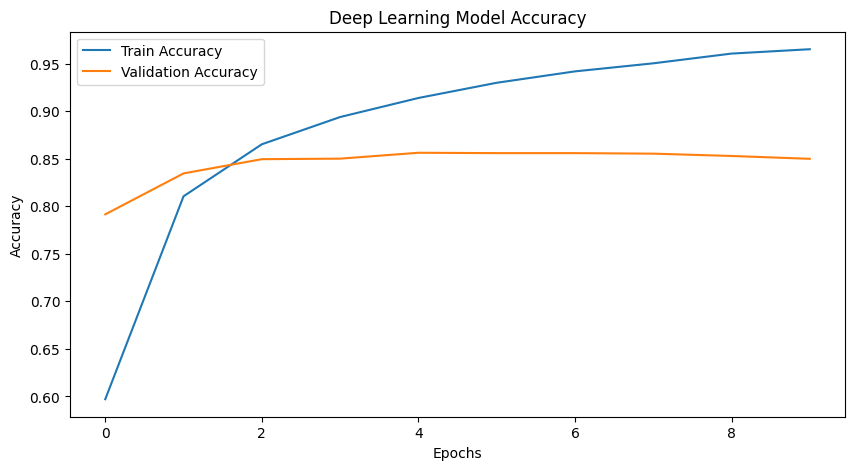

In [12]:
# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Deep Learning Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [13]:
import pickle

# 1. Save the Trained LSTM Model
model.save('sarcasm_model.h5')

# 2. Save the Tokenizer (so the app knows your words)
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("✅ Model and Tokenizer successfully saved to folder!")

✅ Model and Tokenizer successfully saved to folder!
